# Introduction : Analyse du jeu de données MPG

Dans ce tutoriel, nous allons explorer en détail le jeu de données "mpg". Ce jeu de données, initialement publié par la bibliothèque StatLib de l'Université Carnegie Mellon et désormais disponible dans la bibliothèque Seaborn. L'objectif de ce tutoriel est d'explorer la relation entre la consommation de carburant (Miles Per Gallon, ou MPG) et diverses autres caractéristiques de ce jeu de données.

Le jeu de données "mpg" est particulièrement intéressant pour notre étude car il présente une combinaison de caractéristiques discrètes et continues. Il contient :

- 3 caractéristiques discrètes : Ces variables catégorielles nous permettront d'analyser des groupes ou des classifications au sein des données.
- 5 caractéristiques continues : Ces variables numériques nous permettront d'examiner des relations et des tendances quantitatives.

In [3]:
import seaborn as sns
# load a seaborn dataset
mpg_df = sns.load_dataset("mpg")
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Chargement du dataset MPG...

GRAPHIQUE 1 : NUAGE DE POINTS (SCATTER PLOT)
POURQUOI CE GRAPHIQUE ?
- Objectif : Observer la relation entre deux variables continues (le poids et la consommation).
- Justification : Le scatter plot est l'outil ideal pour identifier une correlation. Ici, on voit clairement une correlation negative (plus la voiture est lourde, moins elle parcourt de miles par gallon). L'ajout de la couleur par continent permet de voir que les voitures americaines (usa) sont generalement plus lourdes et moins economiques.


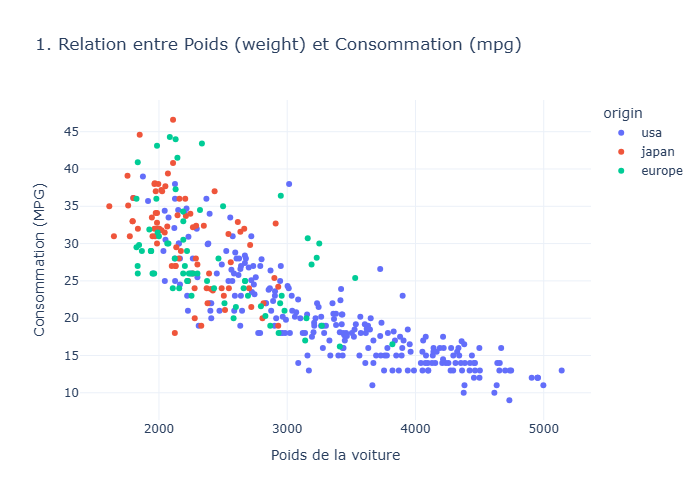


GRAPHIQUE 2 : BOITE A MOUSTACHES (BOX PLOT)
POURQUOI CE GRAPHIQUE ?
- Objectif : Comparer la distribution d'une variable numerique selon des categories.
- Justification : Le box plot est parfait pour comparer la consommation (mpg) entre les differents continents (origin). Il nous permet de voir d'un seul coup d'oeil la mediane, la dispersion des donnees, et les valeurs aberrantes (outliers) pour chaque region de production.


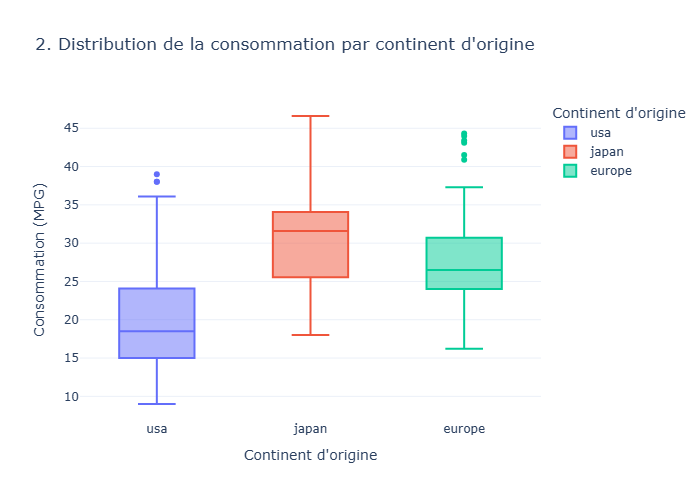


GRAPHIQUE 3 : GRAPHIQUE EN LIGNE (LINE PLOT)
POURQUOI CE GRAPHIQUE ?
- Objectif : Analyser une evolution dans le temps (tendance temporelle).
- Justification : Le graphique en ligne est le standard absolu pour les donnees temporelles. En calculant la moyenne de mpg par annee (model_year), ce graphique montre clairement comment la crise petroliere et les avancees technologiques des annees 70 ont pousse les constructeurs a creer des voitures de plus en plus economiques.


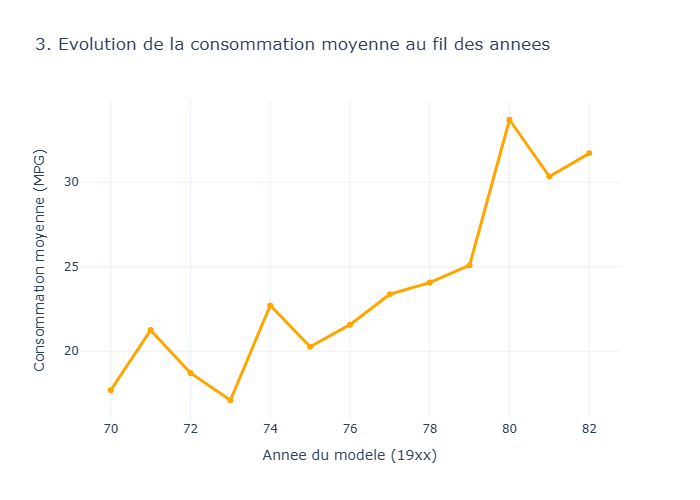


GRAPHIQUE 4 : CARTE DE CHALEUR (HEATMAP)
POURQUOI CE GRAPHIQUE ?
- Objectif : Visualiser la matrice de correlation de toutes les variables numeriques.
- Justification : Au lieu de tracer des dizaines de nuages de points un par un, la heatmap avec les coefficients de correlation permet d'identifier instantanement les relations fortes. Par exemple, le rouge fonce entre 'weight' et 'displacement' indique une très forte correlation positive.


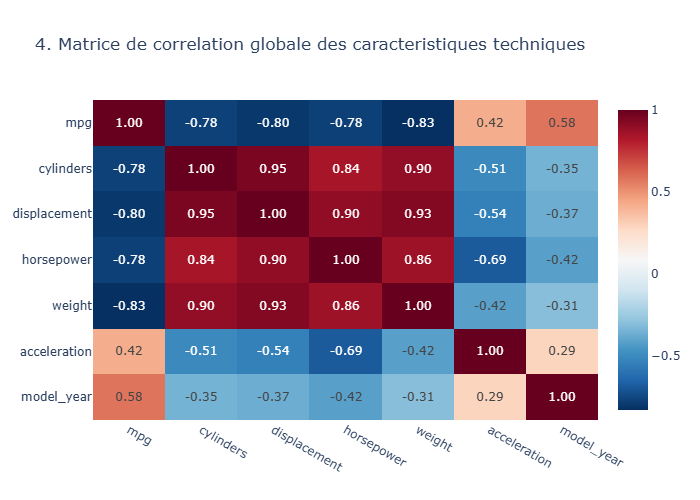

In [4]:
# --- ETAPE 1 : IMPORTATIONS ET CHARGEMENT ---
import seaborn as sns
import pandas as pd
import plotly.express as px
import plotly.io as pio
from IPython.display import display

# Rendu PNG pour affichage propre sur GitHub (sans bug d'accents)
pio.renderers.default = "png" 

print("Chargement du dataset MPG...")
mpg_df = sns.load_dataset("mpg")

print("\n" + "="*50)
print("GRAPHIQUE 1 : NUAGE DE POINTS (SCATTER PLOT)")
print("POURQUOI CE GRAPHIQUE ?")
print("- Objectif : Observer la relation entre deux variables continues (le poids et la consommation).")
print("- Justification : Le scatter plot est l'outil ideal pour identifier une correlation. Ici, on voit clairement une correlation negative (plus la voiture est lourde, moins elle parcourt de miles par gallon). L'ajout de la couleur par continent permet de voir que les voitures americaines (usa) sont generalement plus lourdes et moins economiques.")
print("="*50)

fig1 = px.scatter(
    mpg_df, 
    x="weight", 
    y="mpg", 
    color="origin",
    title="1. Relation entre Poids (weight) et Consommation (mpg)",
    labels={"weight": "Poids de la voiture", "mpg": "Consommation (MPG)"},
    template="plotly_white"
)
fig1.show()


print("\n" + "="*50)
print("GRAPHIQUE 2 : BOITE A MOUSTACHES (BOX PLOT)")
print("POURQUOI CE GRAPHIQUE ?")
print("- Objectif : Comparer la distribution d'une variable numerique selon des categories.")
print("- Justification : Le box plot est parfait pour comparer la consommation (mpg) entre les differents continents (origin). Il nous permet de voir d'un seul coup d'oeil la mediane, la dispersion des donnees, et les valeurs aberrantes (outliers) pour chaque region de production.")
print("="*50)

fig2 = px.box(
    mpg_df, 
    x="origin", 
    y="mpg", 
    color="origin",
    title="2. Distribution de la consommation par continent d'origine",
    labels={"origin": "Continent d'origine", "mpg": "Consommation (MPG)"},
    template="plotly_white"
)
fig2.show()


print("\n" + "="*50)
print("GRAPHIQUE 3 : GRAPHIQUE EN LIGNE (LINE PLOT)")
print("POURQUOI CE GRAPHIQUE ?")
print("- Objectif : Analyser une evolution dans le temps (tendance temporelle).")
print("- Justification : Le graphique en ligne est le standard absolu pour les donnees temporelles. En calculant la moyenne de mpg par annee (model_year), ce graphique montre clairement comment la crise petroliere et les avancees technologiques des annees 70 ont pousse les constructeurs a creer des voitures de plus en plus economiques.")
print("="*50)

# Calcul de la moyenne par annee
avg_mpg_year = mpg_df.groupby('model_year')['mpg'].mean().reset_index()

fig3 = px.line(
    avg_mpg_year, 
    x="model_year", 
    y="mpg", 
    markers=True,
    title="3. Evolution de la consommation moyenne au fil des annees",
    labels={"model_year": "Annee du modele (19xx)", "mpg": "Consommation moyenne (MPG)"},
    template="plotly_white"
)
fig3.update_traces(line_color="orange", line_width=3)
fig3.show()


print("\n" + "="*50)
print("GRAPHIQUE 4 : CARTE DE CHALEUR (HEATMAP)")
print("POURQUOI CE GRAPHIQUE ?")
print("- Objectif : Visualiser la matrice de correlation de toutes les variables numeriques.")
print("- Justification : Au lieu de tracer des dizaines de nuages de points un par un, la heatmap avec les coefficients de correlation permet d'identifier instantanement les relations fortes. Par exemple, le rouge fonce entre 'weight' et 'displacement' indique une très forte correlation positive.")
print("="*50)

# Matrice de correlation (uniquement sur les colonnes numeriques)
numeric_df = mpg_df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

fig4 = px.imshow(
    corr_matrix, 
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="4. Matrice de correlation globale des caracteristiques techniques"
)
fig4.show()